In [1]:
""" Imports and loading the data"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix, ConfusionMatrixDisplay


PROJECT_ROOT = Path.cwd().parent
csv_path = PROJECT_ROOT / "archive" / "neo_v2.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.dtypes

print("Missing values per column:")
df.isnull().sum()   # Each cell 1 / 0 -> adds them together

Shape: (90836, 10)
Missing values per column:


id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

In [2]:
""" Change hazardous from (True/False) to (1/0)"""
df["hazardous_int"] = df["hazardous"].astype(int)
df = df.drop(columns=["hazardous"])  # (boolean) dropped, hazardous_int kept

print("Remaining columns:", list(df.columns))

Remaining columns: ['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous_int']


In [3]:
""" Dropping non-informative columns """
print("Unique values in orbiting_body:", df["orbiting_body"].unique())  # Check for unique values
print("Unique values in sentry_object:", df["sentry_object"].unique())

drop_cols = ["id", "name"]
if df["orbiting_body"].nunique() == 1:  # Distinct value count, exclude Nan
    drop_cols.append("orbiting_body")
if df["sentry_object"].nunique() == 1:
    drop_cols.append("sentry_object")


df = df.drop(columns=drop_cols) # Removes columns from dataframe
print("Dropped columns:", drop_cols)
print("Remaining columns:", list(df.columns))

Unique values in orbiting_body: <StringArray>
['Earth']
Length: 1, dtype: str
Unique values in sentry_object: [False]
Dropped columns: ['id', 'name', 'orbiting_body', 'sentry_object']
Remaining columns: ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


In [4]:
""" Correlation """
numeric_cols_with_min =  ["est_diameter_min", "est_diameter_max",
                        "relative_velocity", "miss_distance", "absolute_magnitude"]

print("Correlation between est_diameter_min and est_diameter_max:",
      df["est_diameter_min"].corr(df["est_diameter_max"]))

print()
print("Correlation of each feature with the target:")
df[numeric_cols_with_min + ["hazardous_int"]].corr()["hazardous_int"]    # Pearsons correlation coefficient

Correlation between est_diameter_min and est_diameter_max: 1.0

Correlation of each feature with the target:


est_diameter_min      0.183363
est_diameter_max      0.183363
relative_velocity     0.191185
miss_distance         0.042302
absolute_magnitude   -0.365267
hazardous_int         1.000000
Name: hazardous_int, dtype: float64

In [5]:
""" Drop est_diameter_min because of correlation with est_diameter_max"""
df = df.drop(columns=["est_diameter_min"])

numeric_cols = ["est_diameter_max", "relative_velocity", "miss_distance", "absolute_magnitude"]
print("Remaining columns:", list(df.columns))

Remaining columns: ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


In [6]:
""" Summary of statistics"""
df[numeric_cols].describe()


,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,0.284947,48066.918918,3.706655e+07,23.527103
std,0.667491,25293.296961,2.235204e+07,2.894086
min,0.001362,203.346433,6.745533e+03,9.230000
25%,0.043057,28619.020645,1.721082e+07,21.340000
50%,0.108153,44190.117890,3.784658e+07,23.700000
75%,0.320656,62923.604633,5.654900e+07,25.700000
max,84.730541,236990.128088,7.479865e+07,33.200000


In [7]:
""" Checking "ratio" between hazardous and non-hazardous"""
print(df["hazardous_int"].value_counts())  # Count how many times hazardous int appears
print()
print(df["hazardous_int"].value_counts(normalize=True) * 100)

hazardous_int
0    81996
1     8840
Name: count, dtype: int64

hazardous_int
0    90.268176
1     9.731824
Name: proportion, dtype: float64


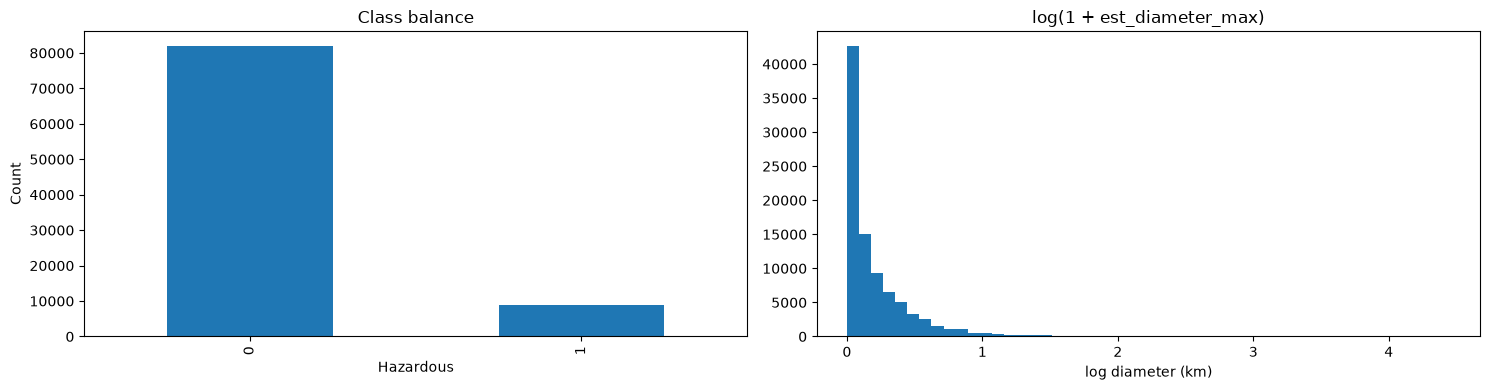

In [8]:
""" Visulaization """
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

df["hazardous_int"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Class balance")
axes[0].set_xlabel("Hazardous")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(df["est_diameter_max"]), bins=50)
axes[1].set_title("log(1 + est_diameter_max)")
axes[1].set_xlabel("log diameter (km)")

plt.tight_layout()
plt.show()

In [9]:
""" Save output, figures and data """
df.to_csv("clean_data.csv", index = False)
fig.savefig("plot_overview.png", dpi = 150)

print("Shape of clean_data.csv:", df.shape)
print("Columns in clean_data.csv", list(df.columns))

Shape of clean_data.csv: (90836, 5)
Columns in clean_data.csv ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


In [10]:
""" Splitting clean_data.csv to train/test data"""
clean_df = pd.read_csv("clean_data.csv")

print("Shape", clean_df.shape)
print("Columns:", list(clean_df.columns))

train_data, test_data = train_test_split(
    clean_df,
    test_size = 0.2,
    stratify=clean_df["hazardous_int"], # Splits hazardous_int evenly
    random_state=42   # Same split each time you run the cell
)

print("\n")
train_data.to_csv("train_data.csv", index=False)  #False for plain csv data
print("train_data.csv saved")
test_data.to_csv("test_data.csv", index=False)
print("test_data.csv saved")
print("\n")
print("Train data shape", train_data.shape)
print(train_data["hazardous_int"].value_counts())
print(train_data["hazardous_int"].value_counts(normalize=True) * 100)
print("\n")
print("Test data shape", test_data.shape)
print(test_data["hazardous_int"].value_counts())
print(test_data["hazardous_int"].value_counts(normalize=True) * 100)

Shape (90836, 5)
Columns: ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


train_data.csv saved
test_data.csv saved


Train data shape (72668, 5)
hazardous_int
0    65596
1     7072
Name: count, dtype: int64
hazardous_int
0    90.268068
1     9.731932
Name: proportion, dtype: float64


Test data shape (18168, 5)
hazardous_int
0    16400
1     1768
Name: count, dtype: int64
hazardous_int
0    90.268604
1     9.731396
Name: proportion, dtype: float64


In [11]:

""" Inte "riktig kod" bara testar lite"""
test = pd.read_csv("test_data.csv")
train = pd.read_csv("train_data.csv")

print(test.head())
print(train.head())


   est_diameter_max  relative_velocity  miss_distance  absolute_magnitude  \
0          1.056915       21779.237137   3.443050e+07               18.75   
1          0.187949       53291.016226   6.862591e+07               22.50   
2          0.040742       43089.046433   2.592726e+07               25.82   
3          0.342011       93246.455599   4.709054e+07               21.20   
4          0.071456       37708.258544   4.232149e+07               24.60   

   hazardous_int  
0              0  
1              0  
2              0  
3              0  
4              0  
   est_diameter_max  relative_velocity  miss_distance  absolute_magnitude  \
0          0.054205       43303.999094   4.814117e+07               25.20   
1          0.067615       21770.790211   5.646643e+07               24.72   
2          0.450858      109358.123029   6.435051e+07               20.60   
3          0.358129       78494.609756   5.595780e+07               21.10   
4          0.015633       19077.749486

In [12]:
""" Pure claude madness vill kolla hur nära vi kommer"""

features = ["est_diameter_max", "relative_velocity", "miss_distance", "absolute_magnitude"]
target = "hazardous_int"

train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# Standardize features (fit on training data only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Logistic regression trained by minimizing log loss (no regularization)
model = LogisticRegression(penalty=None, max_iter=1000)
model.fit(X_train_s, y_train)

# The learned weights w and bias b
w = model.coef_[0]        # shape (4,)
b = model.intercept_[0]
print("w:", dict(zip(features, w.round(4))))
print("b:", round(b, 4))

# Hypothesis: sigma(w^T x + b), computed by hand
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

p_test = sigmoid(X_test_s @ w + b)
print("Matches sklearn:", np.allclose(p_test, model.predict_proba(X_test_s)[:, 1]))

# Log loss, computed by hand and with sklearn
def log_loss_manual(y, p, eps=1e-15):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

print("Log loss (manual):", log_loss_manual(y_test.values, p_test))
print("Log loss (sklearn):", log_loss(y_test, p_test))

# Classify with a 0.5 threshold and check accuracy
y_pred = (p_test >= 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))

w: {'est_diameter_max': np.float64(-1.6892), 'relative_velocity': np.float64(0.1954), 'miss_distance': np.float64(-0.4528), 'absolute_magnitude': np.float64(-3.3708)}
b: -4.0008
Matches sklearn: True
Log loss (manual): 0.2215107238653988
Log loss (sklearn): 0.2215107238653988
Accuracy: 0.9032364597093792


c:\Users\adria\OneDrive\Documents\GitHub\ML_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[[16272   128]
 [ 1630   138]]
TN=16272, FP=128, FN=1630, TP=138
Recall     : 0.07805429864253394
Precision  : 0.518796992481203
Specificity: 0.9921951219512195


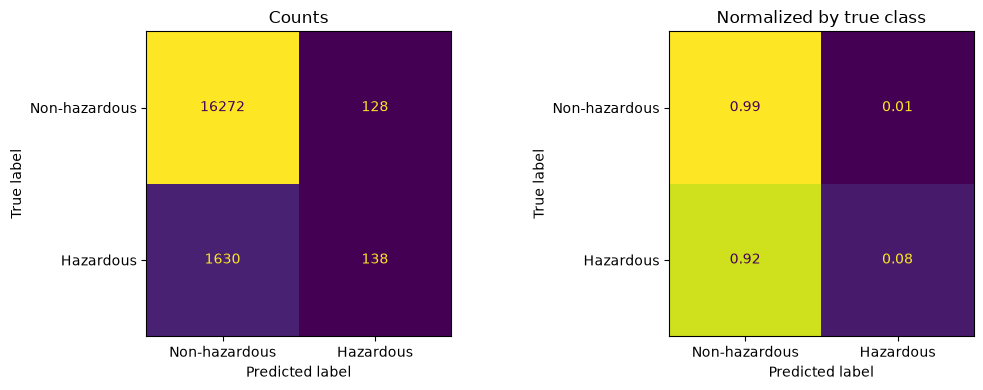

In [13]:
""" Mera Claude madness för att kolla confusion matrixen"""
y_pred = (p_test >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("Recall     :", tp / (tp + fn))
print("Precision  :", tp / (tp + fp) if (tp + fp) else float("nan"))
print("Specificity:", tn / (tn + fp))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw counts
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Non-hazardous", "Hazardous"],
    ax=axes[0], colorbar=False)
axes[0].set_title("Counts")

# Normalized by true class (each row sums to 1)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Non-hazardous", "Hazardous"],
    normalize="true", values_format=".2f", ax=axes[1], colorbar=False)
axes[1].set_title("Normalized by true class")

plt.tight_layout()
plt.show()